# Visualization & Analysis of Bayesian Optimization on SPVVVECTR

*importing modules*

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
from skopt import load
from skopt.plots import plot_objective

*modular function to plot observations for each experiment*

In [114]:
def plot_scatter(csv_filepath, title="SPVVVECTR Observed Trials"):
    """
    Loads BO trial data from CSV and outputs 3d scatter plot.
    Fitness (displacement) is represented by both color (heat) and marker size
    """

    df = pd.read_csv(csv_filepath, nrows=50)

    # setup 3d figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # create 4d scatter plot
    scatter = ax.scatter(
        df['RPM_1'],
        df['RPM_2'],
        df['RPM_3'],
        c=df['Displacement_mm'],
        cmap='inferno',
        s=df['Displacement_mm'] * 0.8, # scaled size of points 
        alpha=0.8,
        edgecolors='w',
        linewidth=0.5
    )

    # format and label
    ax.set_xlabel('Strut 1 (RPM)', labelpad=10)
    ax.set_xlabel('Strut 2 (RPM)', labelpad=10)
    ax.set_xlabel('Strut 3 (RPM)', labelpad=10)
    ax.set_title(title, pad=20, fontsize=14)

    # legend for fitness
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
    cbar.set_label('Displacement (mm)', rotation=270, labelpad=20)

    plt.tight_layout()
    plt.show()

*modular function to plot partial dependence for each experiment*

In [115]:
def plot_partial_dependence(pkl_filepath, title):
    """
    Loads a saved BO model (.pkl) and generates 
    a 2d partial dependence matrix plot for all 3 parameters (RPM_1, RPM_2, RPM_3).
    """

    res = load(pkl_filepath)
    dim_names = ['Strut 1 (RPM)', 'Strut 2 (RPM)', 'Strut 3 (RPM)']

    plot_objective(
        res,
        sample_source='result',
        minimum=res.x, #red star is best phyiscal gait observed
        dimensions=dim_names,
    )

    fig = plt.gcf()
    fig.set_size_inches(12, 12)

    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    for current_ax in fig.axes:
        current_ax.tick_params(axis='x', rotation=45)

    fig.suptitle(f"{title}", fontsize=18, y=0.98)

    plt.show()




*method that outputs the top 5 best rpm combinations that each experiment found*

In [116]:
import pandas as pd

def print_top_5_gaits(csv_filepath, experiment_name="Experiment"):
    """
    Reads a Bayesian Optimization CSV, finds the top 5 highest displacements,
    and prints them as a clean, aligned text table suitable for a code block.
    """
    # 1. Load only the 50 trial rows to avoid the summary block at the bottom
    df = pd.read_csv(csv_filepath, nrows=50)
    
    # 2. Sort by displacement in descending order (highest to lowest)
    top_5 = df.sort_values(by="Displacement_mm", ascending=False).head(5)
    
    # 3. Print the Title
    print(f"=== Top 5 Best Gaits: {experiment_name} ===")
    
    # 4. Print the aligned header
    header = f"{'Rank':<5} | {'Phase':<13} | {'Strut 1':<8} | {'Strut 2':<8} | {'Strut 3':<8} | {'Displacement (mm)':<17}"
    print(header)
    print("-" * len(header))
    
    # 5. Iterate through the top 5 and print aligned rows
    rank = 1
    for index, row in top_5.iterrows():
        phase = row['Phase']
        rpm1 = int(row['RPM_1'])
        rpm2 = int(row['RPM_2'])
        rpm3 = int(row['RPM_3'])
        disp = f"{row['Displacement_mm']:.2f}"
        
        # The :< number forces the text to take up exactly that many spaces
        print(f"{rank:<5} | {phase:<13} | {rpm1:<8} | {rpm2:<8} | {rpm3:<8} | {disp:<17}")
        rank += 1
        

*method that outputs the convergence plot comparing all 3 experiments*

In [117]:
def plot_convergence():
    # file paths
    experiments = {
        "Random Priors": "./bo_results_random_priors/bo_results_20260728_141100.csv",
        "LHS Priors": "./bo_results_lhs_priors/bo_results_20260728_143448.csv",
        "No Priors": "./bo_results_no_priors/bo_results_20260728_150129.csv"
    }

    plt.figure(figsize=(10, 6))

    for label, filepath in experiments.items():
        df = pd.read_csv(filepath, nrows=50)
        df['Best_So_Far'] = df['Displacement_mm'].cummax()
        plt.plot(df['Trial_Number'], df['Best_So_Far'], label=label, marker='o', markersize=4)

    # formatting
    plt.xlabel('Trial Number', fontsize=12)
    plt.ylabel('Best Displacement (mm)', fontsize=12)
    plt.title('Bayesian Optimization Convergence', fontsize=14, pad=15)

    # legend
    plt.legend(loc="upper left")
    plt.grid(True, linestyle='-', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Experiment 1: Random Priors

## Observed gaits 
3 dimensions for each strut RPM, where fitness (displacement) is represented by color.

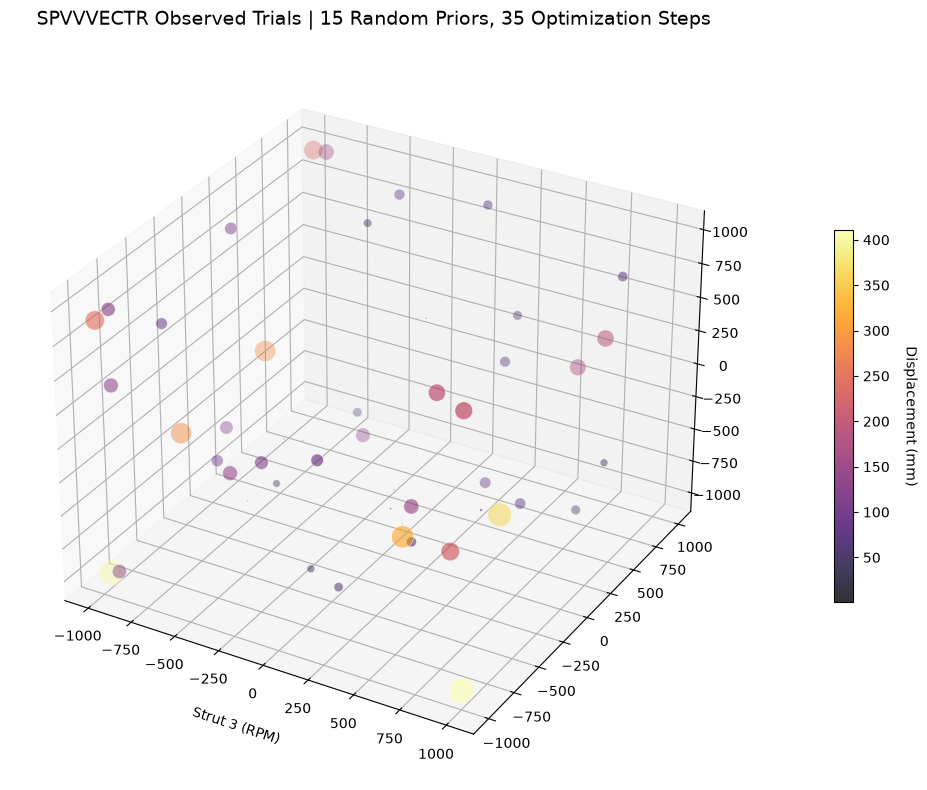

In [118]:
plot_scatter('./bo_results_random_priors/bo_results_20260728_141100.csv', title="SPVVVECTR Observed Trials | 15 Random Priors, 35 Optimization Steps")

The top 5 best rpm-combinations for this experiment are printed below:

In [119]:
print_top_5_gaits('./bo_results_random_priors/bo_results_20260728_141100.csv', "15 Random Priors, 35 Optimization Steps")

=== Top 5 Best Gaits: 15 Random Priors, 35 Optimization Steps ===
Rank  | Phase         | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | 1000     | -1000    | -1000    | 410.76           
2     | Optimization  | -974     | -970     | -991     | 404.64           
3     | Optimization  | 789      | -252     | -331     | 364.35           
4     | Prior         | 592      | -844     | -154     | 318.03           
5     | Optimization  | -847     | -508     | -196     | 282.12           


## Partial Dependency Plot
insert explanation here

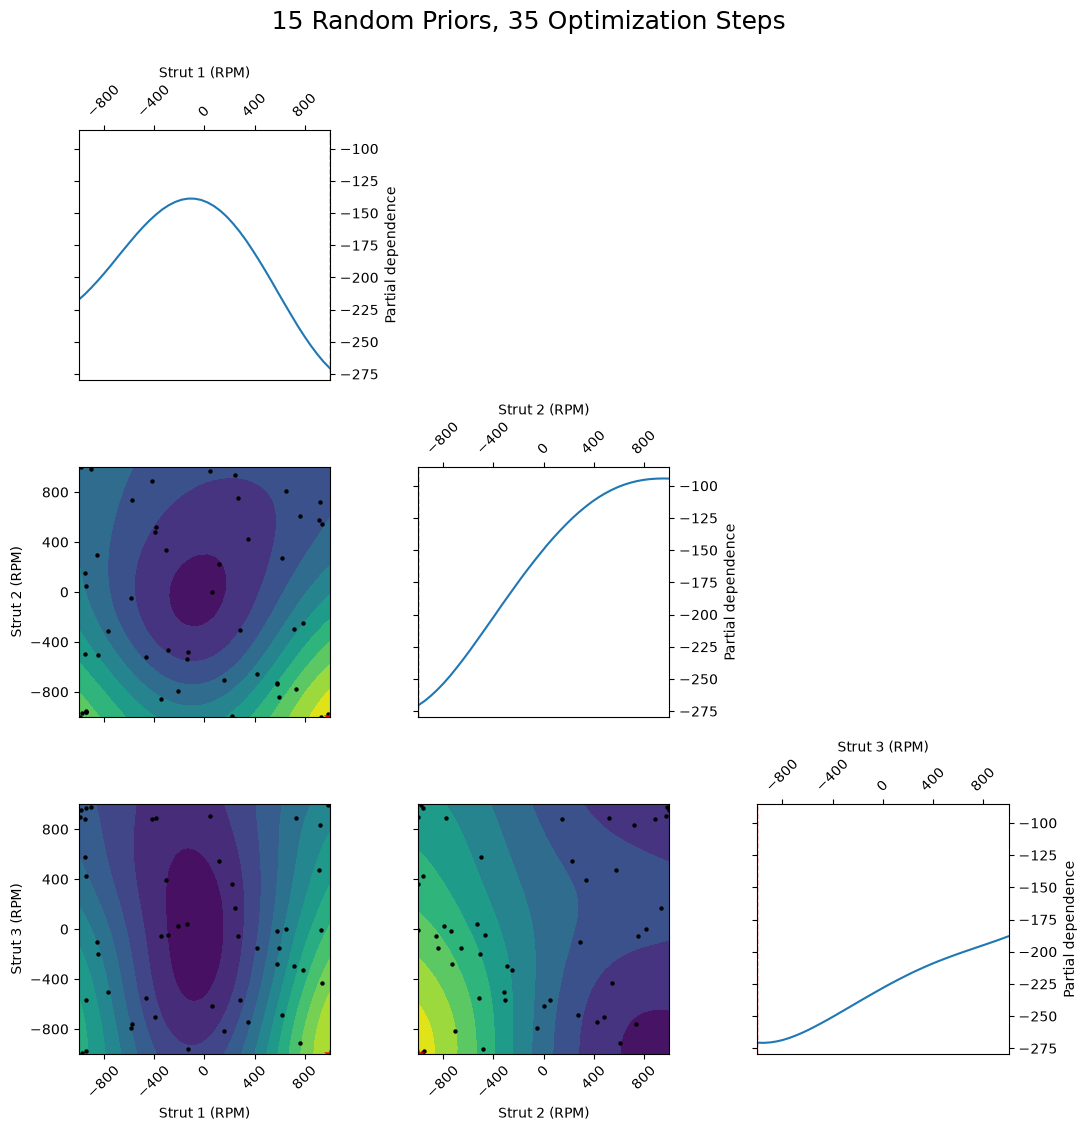

In [120]:
plot_partial_dependence('./bo_results_random_priors/bo_model_20260728_141100.pkl', title="15 Random Priors, 35 Optimization Steps")

# Experiment 2: Latin Hypercube Sampling Priors

## Observed gaits 
3 dimensions for each strut RPM, where fitness (displacement) is represented by color.

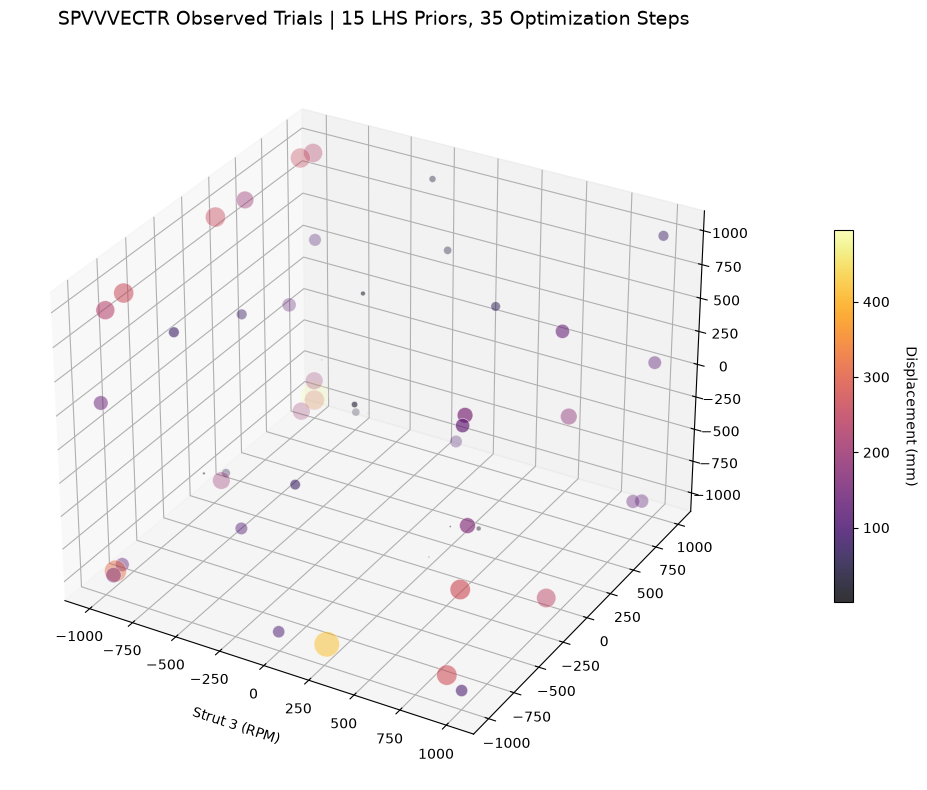

In [121]:
plot_scatter('./bo_results_lhs_priors/bo_results_20260728_143448.csv', title="SPVVVECTR Observed Trials | 15 LHS Priors, 35 Optimization Steps")

The top 5 best rpm-combinations for this experiment are printed below:

In [122]:
print_top_5_gaits('./bo_results_lhs_priors/bo_results_20260728_143448.csv', "15 LHS Priors, 35 Optimization Steps")

=== Top 5 Best Gaits: 15 LHS Priors, 35 Optimization Steps ===
Rank  | Phase         | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | -1000    | 1000     | -963     | 495.06           
2     | Optimization  | 258      | -989     | -989     | 419.55           
3     | Optimization  | -964     | -963     | -974     | 310.05           
4     | Optimization  | 979      | -987     | -269     | 268.92           
5     | Optimization  | 911      | -984     | -936     | 268.06           


## Partial Dependency Plot
insert explanation here

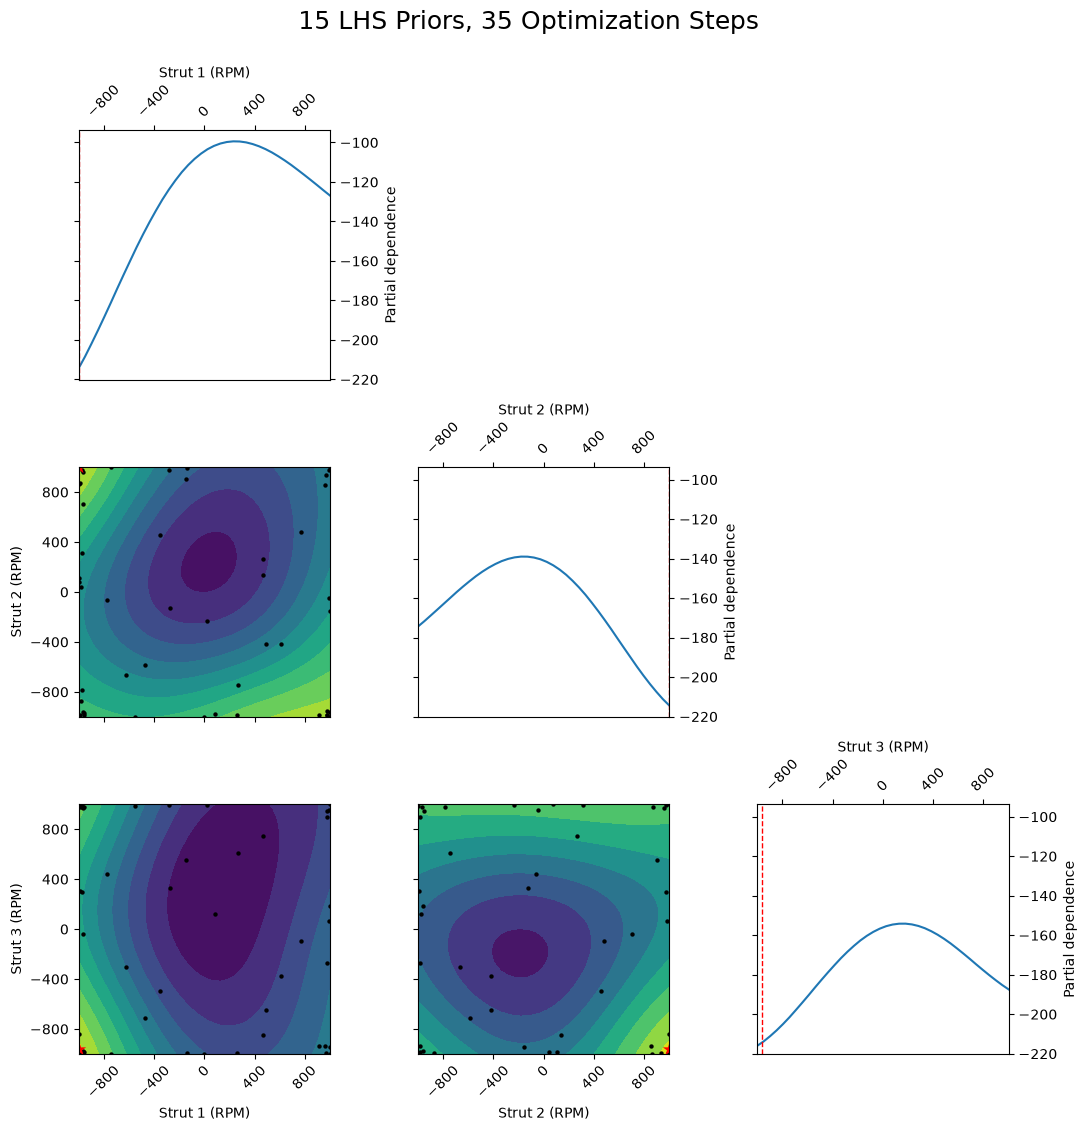

In [123]:
plot_partial_dependence('./bo_results_lhs_priors/bo_model_20260728_143448.pkl', title="15 LHS Priors, 35 Optimization Steps")

# Experiment 3: No Priors

## Observed gaits 
3 dimensions for each strut RPM, where fitness (displacement) is represented by color.

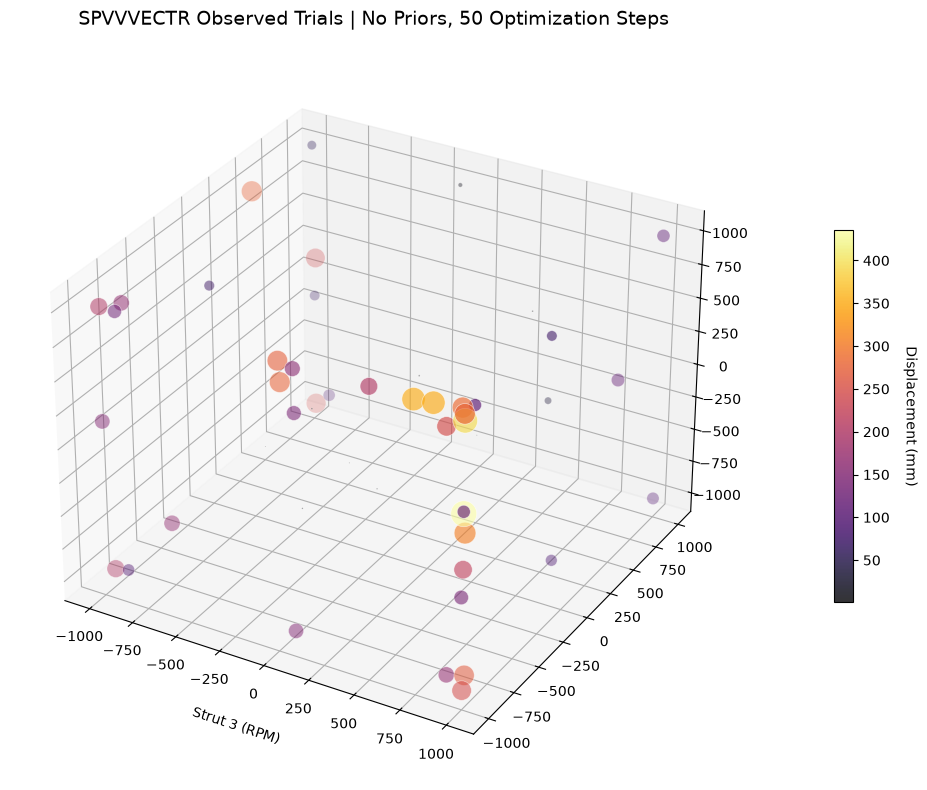

In [124]:
plot_scatter('./bo_results_no_priors/bo_results_20260728_150129.csv', title="SPVVVECTR Observed Trials | No Priors, 50 Optimization Steps")

The top 5 best rpm-combinations for this experiment are printed below:

In [125]:
print_top_5_gaits('./bo_results_no_priors/bo_results_20260728_150129.csv', '15 Random Priors, 35 Optimization Steps')

=== Top 5 Best Gaits: 15 Random Priors, 35 Optimization Steps ===
Rank  | Phase         | Strut 1  | Strut 2  | Strut 3  | Displacement (mm)
--------------------------------------------------------------------------
1     | Optimization  | 1000     | -1000    | 297      | 435.57           
2     | Optimization  | 993      | -984     | 939      | 395.49           
3     | Optimization  | 734      | -1000    | 1000     | 352.87           
4     | Optimization  | 828      | -983     | 1000     | 351.37           
5     | Optimization  | 997      | -980     | 143      | 305.52           


## Partial Dependency Plot
insert explanation here

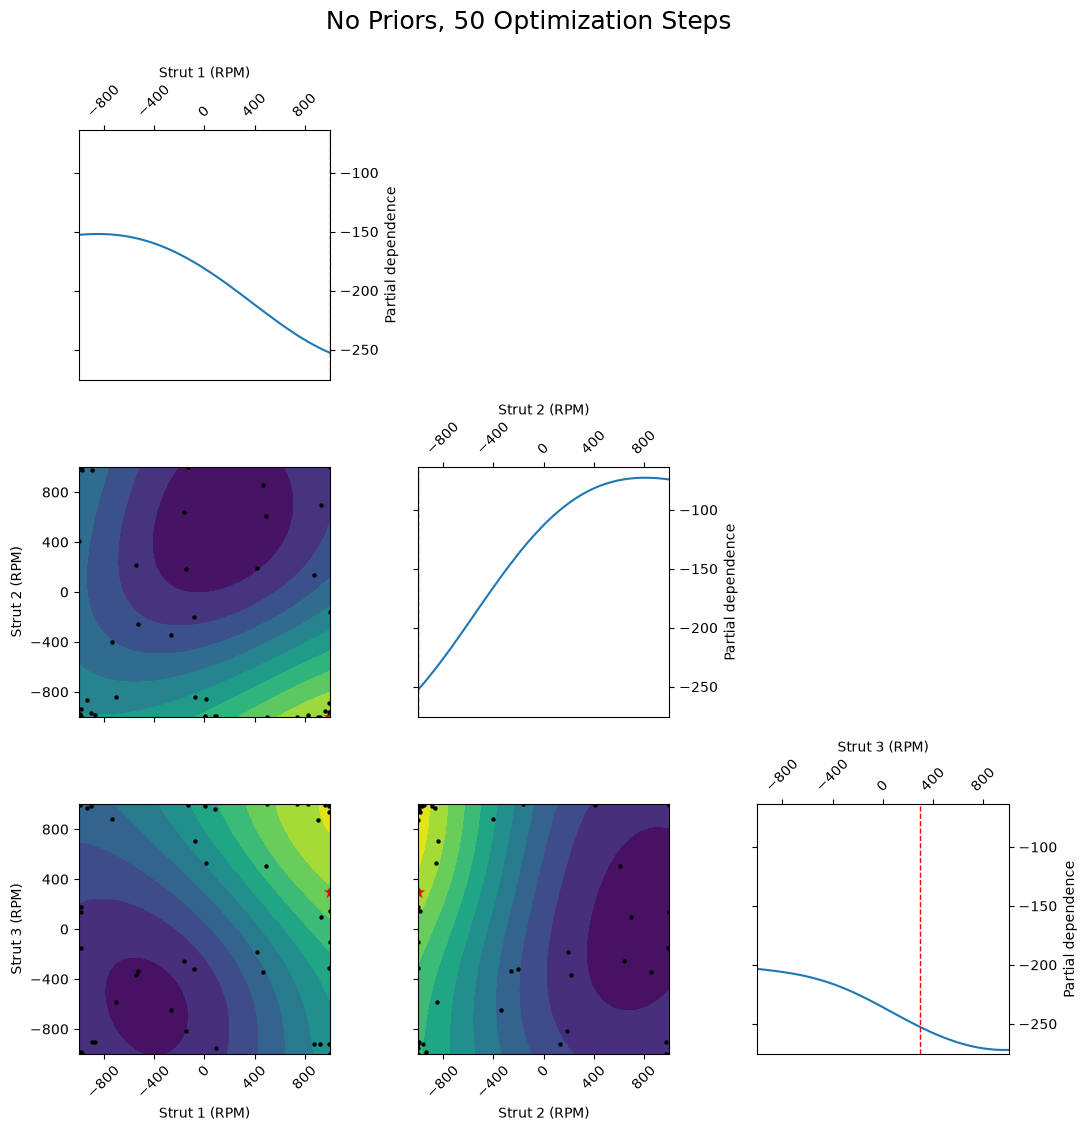

In [126]:
plot_partial_dependence('./bo_results_no_priors/bo_model_20260728_150129.pkl', title="No Priors, 50 Optimization Steps")

# Convergence Plot 
Each experiments max fitness, and how long it took each one to get there 

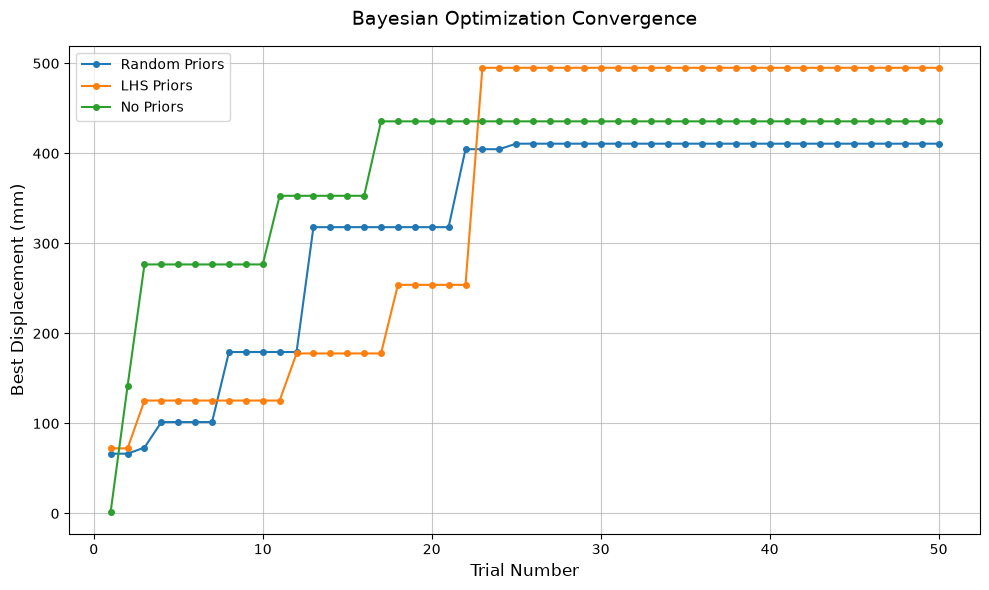

In [127]:
plot_convergence()